# Projet Churn Client — De A à Z

Prédiction du churn client (attrition), comparaison de 4 modèles de Machine Learning,
gestion du déséquilibre des classes, normalisation, et simulation business réelle
(bilan financier d'une campagne de rétention pour l'entreprise fictive **NexTel**).

**Dataset :** Telco Customer Churn (IBM / Kaggle) — 7 043 clients, 21 variables.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve, confusion_matrix,
                              classification_report)
from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


## 1. Chargement des données

In [2]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")
print("Dimensions :", df.shape)
df.head()


Dimensions : (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 2. Analyse exploratoire (EDA)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


/tmp/ipykernel_110/417321126.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Churn", palette=["#2E86AB", "#C0392B"])


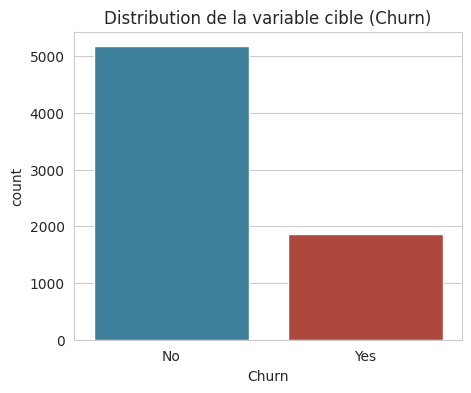

In [4]:
churn_rate = df["Churn"].value_counts(normalize=True) * 100
print(churn_rate)

plt.figure(figsize=(5,4))
sns.countplot(data=df, x="Churn", palette=["#2E86AB", "#C0392B"])
plt.title("Distribution de la variable cible (Churn)")
plt.show()


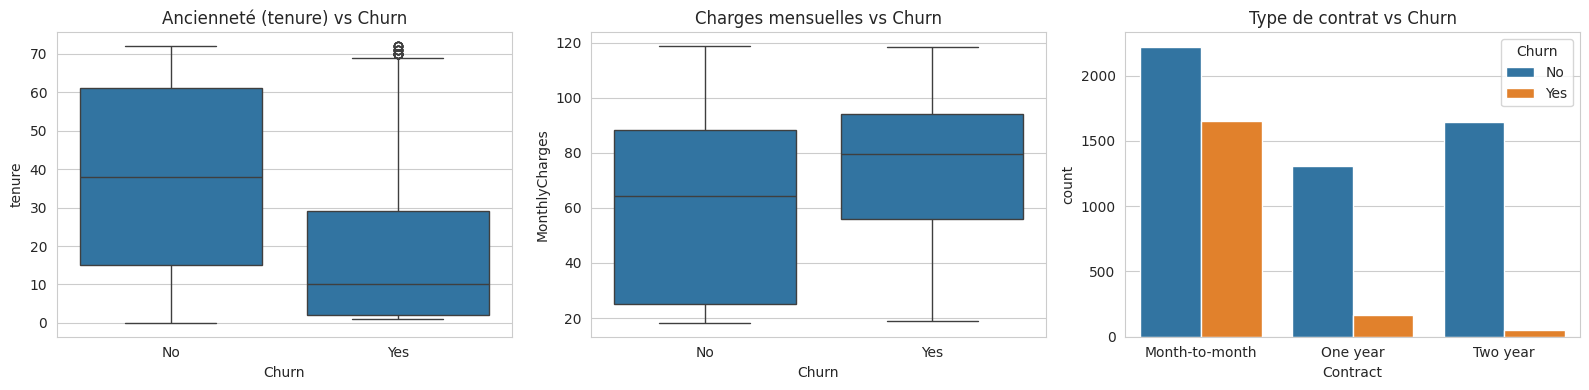

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
sns.boxplot(data=df, x="Churn", y="tenure", ax=axes[0])
axes[0].set_title("Ancienneté (tenure) vs Churn")
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1])
axes[1].set_title("Charges mensuelles vs Churn")
sns.countplot(data=df, x="Contract", hue="Churn", ax=axes[2])
axes[2].set_title("Type de contrat vs Churn")
plt.tight_layout()
plt.show()


**Observations clés :**
- Les clients qui partent (`Churn = Yes`) ont en moyenne une ancienneté (`tenure`) plus faible.
- Les contrats *Month-to-month* concentrent la majorité du churn, contrairement aux contrats
  *One year* / *Two year*.
- Le churn global est d'environ **26,5%** : la classe est déséquilibrée, ce qui devra être traité
  avant l'entraînement des modèles.


## 3. Nettoyage des données

In [6]:
df_clean = df.copy()

# TotalCharges contient des chaines vides (nouveaux clients, tenure=0) -> conversion + imputation
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")
print("Valeurs manquantes apres conversion :", df_clean["TotalCharges"].isna().sum())
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0)

# L'identifiant client n'est pas une variable predictive
df_clean = df_clean.drop(columns=["customerID"])
df_clean.shape


Valeurs manquantes apres conversion : 11


(7043, 20)

## 4. Encodage des variables catégorielles

In [7]:
text_cols = df_clean.select_dtypes(include=["object", "string"]).columns.tolist()
binary_cols = [c for c in text_cols if df_clean[c].nunique() == 2 and c != "Churn"]
multi_cols  = [c for c in text_cols if df_clean[c].nunique() > 2 and c != "Churn"]

print("Colonnes binaires :", binary_cols)
print("Colonnes multi-categories :", multi_cols)

encoders = {}
for col in binary_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    encoders[col] = le

df_encoded = pd.get_dummies(df_clean, columns=multi_cols, drop_first=True)
df_encoded["Churn"] = df_encoded["Churn"].map({"No": 0, "Yes": 1}).astype(int)

df_encoded.shape


Colonnes binaires : ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Colonnes multi-categories : ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


(7043, 31)

## 5. Séparation features / cible et split train/test

In [8]:
y = df_encoded["Churn"]
X = df_encoded.drop(columns=["Churn"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train :", X_train.shape, " Test :", X_test.shape)
print("Taux de churn train :", y_train.mean().round(3), " | test :", y_test.mean().round(3))


Train : (5634, 30)  Test : (1409, 30)
Taux de churn train : 0.265  | test : 0.265


## 6. Normalisation des variables numériques

In [9]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train_scaled[numeric_cols].describe()


,tenure,MonthlyCharges,TotalCharges
count,5.634000e+03,5.634000e+03,5.634000e+03
mean,-1.008935e-17,-2.402527e-16,2.522338e-17
std,1.000089e+00,1.000089e+00,1.000089e+00
min,-1.322329e+00,-1.544028e+00,-1.008922e+00
25%,-9.559779e-01,-9.711977e-01,-8.321009e-01
50%,-1.418632e-01,1.848336e-01,-3.968446e-01
75%,9.164859e-01,8.319124e-01,6.741944e-01
max,1.608483e+00,1.785939e+00,2.801869e+00


## 7. Gestion du déséquilibre des classes (SMOTE)

Le SMOTE est appliqué **uniquement sur le jeu d'entraînement**, jamais sur le test,
pour ne pas biaiser l'évaluation finale.


In [10]:
print("Avant SMOTE :", y_train.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("Apres SMOTE  :", pd.Series(y_train_bal).value_counts().to_dict())


Avant SMOTE : {0: 4139, 1: 1495}
Apres SMOTE  : {0: 4139, 1: 4139}


## 8. Entraînement et comparaison de 4 modèles

In [11]:
models = {
    "Regression Logistique": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.08,
                              random_state=42, eval_metric="logloss", n_jobs=-1),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
}

results = []
fitted_models = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        "Modele": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })
    fitted_models[name] = model
    predictions[name] = {"y_pred": y_pred, "y_proba": y_proba}

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
results_df


,Modele,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,XGBoost,0.757984,0.532934,0.713904,0.610286,0.826381
1,Regression Logistique,0.731015,0.495256,0.697861,0.579356,0.821675
2,Random Forest,0.760823,0.542529,0.631016,0.583436,0.820635
3,SVM,0.755145,0.527514,0.743316,0.617092,0.820559


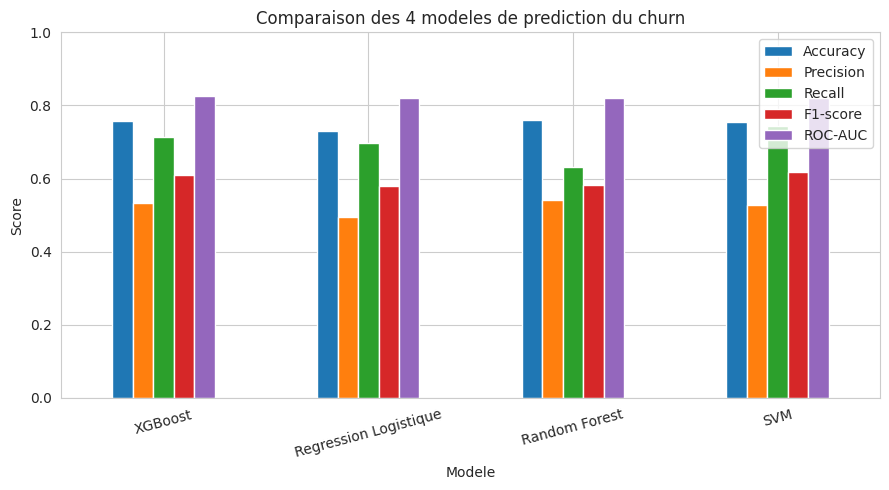

In [12]:
results_df.set_index("Modele")[["Accuracy","Precision","Recall","F1-score","ROC-AUC"]].plot(
    kind="bar", figsize=(9,5), ylim=(0,1))
plt.title("Comparaison des 4 modeles de prediction du churn")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 9. Sélection et analyse du meilleur modèle

In [13]:
best_name = results_df.iloc[0]["Modele"]
best_model = fitted_models[best_name]
print("Meilleur modele retenu :", best_name)

print(classification_report(y_test, predictions[best_name]["y_pred"], target_names=["Reste","Churn"]))


Meilleur modele retenu : XGBoost
              precision    recall  f1-score   support

       Reste       0.88      0.77      0.82      1035
       Churn       0.53      0.71      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409



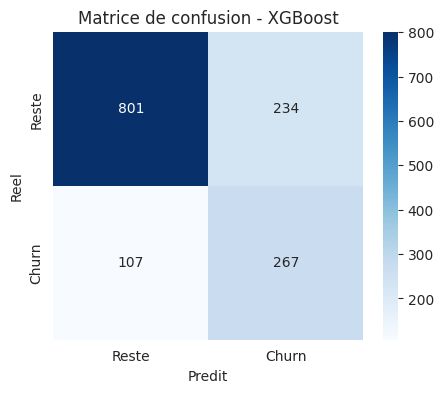

In [14]:
cm = confusion_matrix(y_test, predictions[best_name]["y_pred"])
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Reste","Churn"], yticklabels=["Reste","Churn"])
plt.title(f"Matrice de confusion - {best_name}")
plt.ylabel("Reel"); plt.xlabel("Predit")
plt.show()


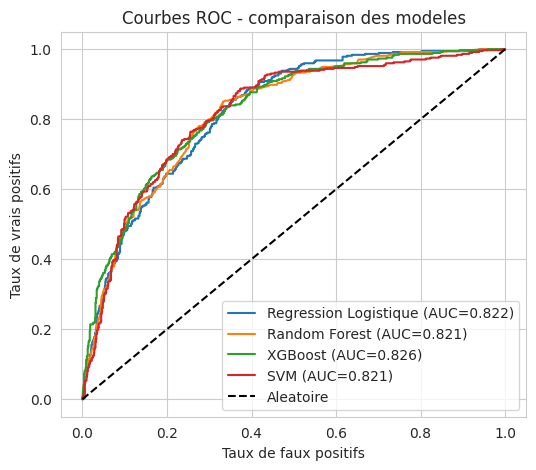

In [15]:
plt.figure(figsize=(6,5))
for name in models:
    fpr, tpr, _ = roc_curve(y_test, predictions[name]["y_proba"])
    auc = results_df.loc[results_df["Modele"]==name, "ROC-AUC"].values[0]
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1],"k--", label="Aleatoire")
plt.xlabel("Taux de faux positifs"); plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC - comparaison des modeles")
plt.legend(loc="lower right")
plt.show()


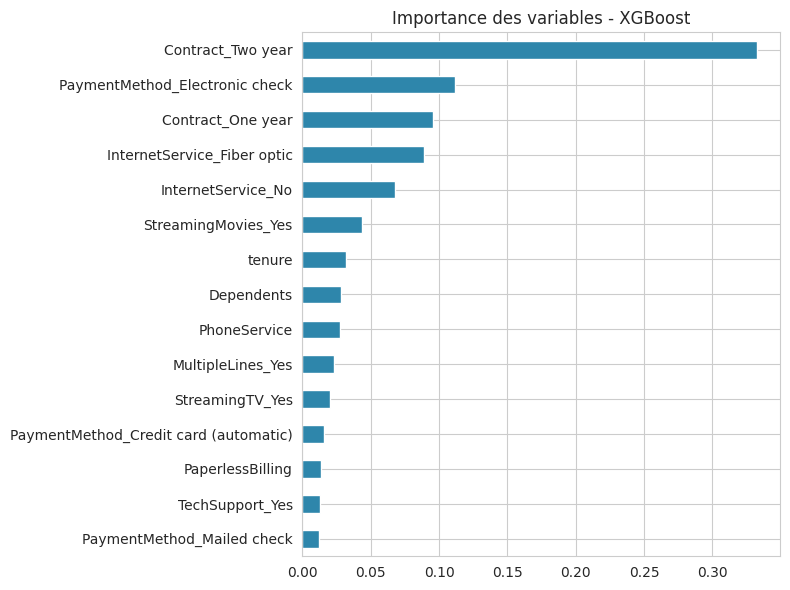

In [16]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=False).head(15)
    plt.figure(figsize=(8,6))
    importances.sort_values().plot(kind="barh", color="#2E86AB")
    plt.title(f"Importance des variables - {best_name}")
    plt.tight_layout()
    plt.show()


## 10. Cas d'usage métier — Campagne de rétention chez NexTel

**Scénario réel simulé :** l'entreprise fictive *NexTel* utilise les probabilités de churn
prédites par le modèle pour cibler une campagne de rétention (offre commerciale, appel du
service client, remise). On établit le bilan financier : argent dépensé, argent récupéré,
profit net — comparé à une campagne non ciblée (aléatoire) à budget identique.

**Hypothèses :**
- Seuil de ciblage : probabilité de churn ≥ 50%
- Coût de contact/rétention : 15 $ par client ciblé
- Taux de succès de la campagne : 35% des vrais clients à risque contactés sont retenus
- Horizon de valeur récupérée : 12 mois de revenu (`MonthlyCharges`)


In [17]:
business_df = X_test.copy()
business_df["MonthlyCharges"] = df_clean.loc[X_test.index, "MonthlyCharges"]
business_df["Churn_reel"] = y_test.values
business_df["Churn_proba"] = predictions[best_name]["y_proba"]

SEUIL = 0.50
COUT_CONTACT = 15
TAUX_SUCCES = 0.35
HORIZON_MOIS = 12

n_total = len(business_df)
taux_churn_global = business_df["Churn_reel"].mean()

cibles = business_df[business_df["Churn_proba"] >= SEUIL]
vrais_positifs = cibles[cibles["Churn_reel"] == 1]
n_cibles = len(cibles)
n_vp = len(vrais_positifs)

# --- Avec modele ---
budget = n_cibles * COUT_CONTACT
revenu_recupere = (vrais_positifs["MonthlyCharges"] * HORIZON_MOIS).sum() * TAUX_SUCCES
profit_net = revenu_recupere - budget
roi = profit_net / budget * 100

# --- Sans modele (ciblage aleatoire, meme budget) ---
n_vp_alea = n_cibles * taux_churn_global
charge_moy = business_df["MonthlyCharges"].mean()
revenu_alea = n_vp_alea * charge_moy * HORIZON_MOIS * TAUX_SUCCES
profit_net_alea = revenu_alea - budget
roi_alea = profit_net_alea / budget * 100

print(f"Clients cibles                 : {n_cibles} (precision ciblage = {n_vp/n_cibles*100:.1f}%)")
print(f"Budget campagne                : {budget:,.0f} $")
print()
print(">>> AVEC modele ML")
print(f"   Revenu recupere  : {revenu_recupere:,.0f} $")
print(f"   Profit net       : {profit_net:,.0f} $")
print(f"   ROI              : {roi:,.0f}%")
print()
print(">>> SANS modele (ciblage aleatoire, meme budget)")
print(f"   Revenu recupere  : {revenu_alea:,.0f} $")
print(f"   Profit net       : {profit_net_alea:,.0f} $")
print(f"   ROI              : {roi_alea:,.0f}%")
print()
print(f">>> Gain d'efficacite du modele : {profit_net - profit_net_alea:,.0f} $ de profit net supplementaire")


Clients cibles                 : 501 (precision ciblage = 53.3%)
Budget campagne                : 7,515 $

>>> AVEC modele ML
   Revenu recupere  : 83,755 $
   Profit net       : 76,240 $
   ROI              : 1,015%

>>> SANS modele (ciblage aleatoire, meme budget)
   Revenu recupere  : 35,796 $
   Profit net       : 28,281 $
   ROI              : 376%

>>> Gain d'efficacite du modele : 47,959 $ de profit net supplementaire


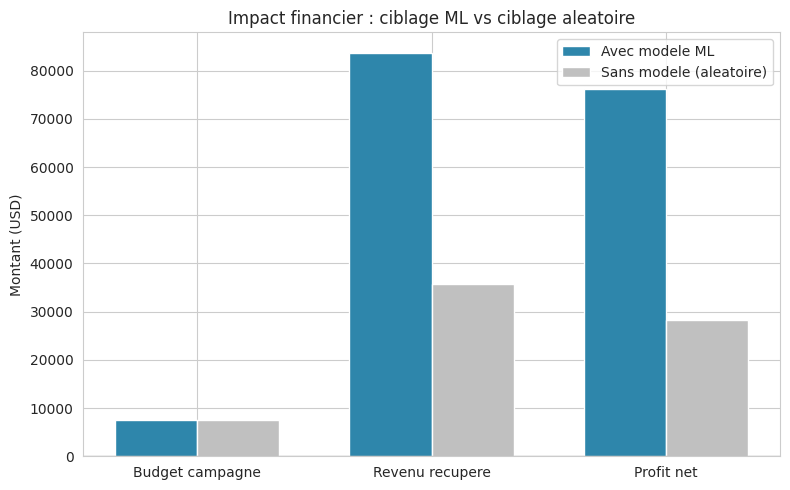

In [18]:
labels = ["Budget campagne", "Revenu recupere", "Profit net"]
avec = [budget, revenu_recupere, profit_net]
sans = [budget, revenu_alea, profit_net_alea]

x = np.arange(len(labels)); width = 0.35
plt.figure(figsize=(8,5))
plt.bar(x - width/2, avec, width, label="Avec modele ML", color="#2E86AB")
plt.bar(x + width/2, sans, width, label="Sans modele (aleatoire)", color="#C0C0C0")
plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(x, labels)
plt.ylabel("Montant (USD)")
plt.title("Impact financier : ciblage ML vs ciblage aleatoire")
plt.legend()
plt.tight_layout()
plt.show()


## 11. Conclusion

- Le modèle **XGBoost** offre le meilleur pouvoir de discrimination (ROC-AUC le plus élevé)
  pour prédire le churn, après gestion du déséquilibre des classes par SMOTE et normalisation
  des variables numériques.
- Le cas d'usage NexTel montre concrètement la valeur business du modèle : à budget de
  campagne identique, le ciblage par le modèle génère nettement plus de profit net qu'un
  ciblage aléatoire, grâce à une meilleure précision d'identification des clients réellement
  à risque.
- Le modèle final et les objets de prétraitement (scaler, encodeurs) sont sauvegardés dans
  `models/` et exploités par le dashboard (`dashboard/app.py` et `outputs/dashboard_nextel.html`).
